# 온라인 제품 판매량 예측 모델 (Advanced Sales Prediction)

본 노트북은 과거 제품 판매량과 브랜드 검색량 데이터를 기반으로 향후 제품 판매량을 예측하는 모델링 프로젝트입니다.

## 1. 데이터셋 컬럼별 설명

### train.csv
- **ID**: 제품별 고유 식별자
- **제품**: 제품 코드
- **대분류/중분류/소분류**: 제품 계층 구조

|**단계**|**명칭**|**예시 (가전)**|**예시 (식품)**|**특징**|
|---|---|---|---|---|
|**대분류**|`C001`|**주방가전**|**가공식품**|가장 큰 산업군 또는 제품군|
|**중분류**|`C002`|전자레인지|라면/면류|대분류를 용도별로 쪼갠 것|
|**소분류**|`C003`|복합오븐레인지|컵라면|실제 구매하는 구체적 품목|

- **브랜드**: 제품의 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 판매량

### brand_keyword_cnt.csv
- **브랜드**: 브랜드 정보
- **2022-01-01 ~ 2023-04-04**: 일별 해당 브랜드의 검색 빈도 (정규화됨)

### product_info.csv
- **제품**: 제품 코드
- **제품특성**: 제품의 상세 스펙/설명 (텍스트 데이터)

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')
plt.rc('font', family='Malgun Gothic') # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드 및 초기 탐색

In [91]:
train = pd.read_csv('./data/train.csv')
brand_keyword = pd.read_csv('./data/brand_keyword_cnt.csv')
product_info = pd.read_csv('./data/product_info.csv')

print(f"Train Data: {train.shape}")
print(f"brand_keyword Data: {brand_keyword.shape}")
print(f"Product Info: {product_info.shape}")
display(train.head(3))

Train Data: (15890, 465)
brand_keyword Data: (3170, 460)
Product Info: (12778, 2)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
sales = pd.read_csv('./data/sales.csv')
print(f"Sales Data Shape: {sales.shape}")
display(sales.head(5))

Sales Data Shape: (15890, 465)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,22400,67200,44800,0,0,44800,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
sales = pd.read_csv('./data/sales.csv')

diff_cols = set(sales.columns) - set(train.columns)
print(f"sales.csv에만 있는 컬럼: {diff_cols}")

diff_cols_train = set(train.columns) - set(sales.columns)
print(f"train.csv에만 있는 컬럼: {diff_cols_train}")

sales.csv에만 있는 컬럼: set()
train.csv에만 있는 컬럼: set()


In [4]:
print("--- train 마지막 컬럼 5개 ---")
print(train.columns[-5:].tolist())

print("\n--- sales 마지막 컬럼 5개 ---")
print(sales.columns[-5:].tolist())

print(f"\n[최종 확인] Train: {train.shape} / Sales: {sales.shape}")

--- train 마지막 컬럼 5개 ---
['2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04']

--- sales 마지막 컬럼 5개 ---
['2023-03-31', '2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04']

[최종 확인] Train: (15890, 465) / Sales: (15890, 465)


train.csv와 sales.csv는 동일한 데이터임을 확인할 수 있습니다.

In [8]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 15890 entries, 0 to 15889
Columns: 465 entries, ID to 2023-04-04
dtypes: int64(460), str(5)
memory usage: 56.4 MB
None


In [10]:
print(train.iloc[0, 5:])

브랜드           B002-00001
2022-01-01             0
2022-01-02             0
2022-01-03             0
2022-01-04             0
                 ...    
2023-03-31             0
2023-04-01             0
2023-04-02             0
2023-04-03             0
2023-04-04             0
Name: 0, Length: 460, dtype: object


In [92]:
# 전체 데이터 중 0의 비율 확인
date_cols = train.columns[6:]
total_elements = train[date_cols].size
zero_count = (train[date_cols] == 0).sum().sum()

print(f"전체 판매 데이터 중 0의 개수: {zero_count}")
print(f"전체 대비 0의 비중: {zero_count / total_elements * 100:.2f}%")

전체 판매 데이터 중 0의 개수: 4652860
전체 대비 0의 비중: 63.79%


0의 비중이 63.79%로 매우 많은 비중을 차지함을 알 수 있습니다.

In [12]:
train['대분류'].value_counts()

대분류
B002-C001-0002    10954
B002-C001-0001     3768
B002-C001-0005      613
B002-C001-0003      444
B002-C001-0004      111
Name: count, dtype: int64

전체 제품은 총 5개의 대분류로 구성되어 있으며, 카테고리별 제품 수 차이가 매우 큽니다.<br> 특히 B002-C001-0002 대분류가 10,954개로 전체 제품(15,890개)의 약 69%를 차지하는 압도적인 주력 카테고리임을 확인했습니다.

In [45]:
# 결측치 비율 계산
null_counts = train.isnull().sum()
null_percentage = (null_counts / len(train)) * 100
print(null_counts)

ID            0
제품            0
대분류           0
중분류           0
소분류           0
             ..
2023-03-31    0
2023-04-01    0
2023-04-02    0
2023-04-03    0
2023-04-04    0
Length: 465, dtype: int64


In [8]:
# 결측치가 있는 컬럼만 출력
print(null_percentage[null_percentage > 0])

Series([], dtype: float64)


결측치가 하나도 없습니다.

## 3. 탐색적 데이터 분석 (EDA)

### 3.1 제품 분포

In [93]:
# 대분류 비율 확인 (상위 20개)
mid_category_ratio = train['대분류'].value_counts(normalize=True).head(20) * 100
mid_category_count = train['대분류'].value_counts().head(20)

mid_df = pd.DataFrame({
    '개수': mid_category_count,
    '비율(%)': mid_category_ratio.round(2)
})
print("--- 대분류 상위 20개 비율 ---")
print(mid_df)

print("\n" + "="*30 + "\n")

# 브랜드 비율 확인 (상위 20개)
brand_ratio = train['브랜드'].value_counts(normalize=True).head(20) * 100
brand_count = train['브랜드'].value_counts().head(20)

brand_df = pd.DataFrame({
    '개수': brand_count,
    '비율(%)': brand_ratio.round(2)
})
print("--- 브랜드 상위 20개 비율 ---")
print(brand_df)

--- 대분류 상위 20개 비율 ---
                   개수  비율(%)
대분류                         
B002-C001-0002  10954  68.94
B002-C001-0001   3768  23.71
B002-C001-0005    613   3.86
B002-C001-0003    444   2.79
B002-C001-0004    111   0.70


--- 브랜드 상위 20개 비율 ---
             개수  비율(%)
브랜드                   
B002-00266  153   0.96
B002-00894  153   0.96
B002-00680  148   0.93
B002-00434  136   0.86
B002-02052  113   0.71
B002-02123   94   0.59
B002-02227   94   0.59
B002-02439   91   0.57
B002-01545   90   0.57
B002-02455   89   0.56
B002-03417   88   0.55
B002-01138   86   0.54
B002-00669   78   0.49
B002-01851   78   0.49
B002-01905   76   0.48
B002-02492   76   0.48
B002-01220   72   0.45
B002-02370   72   0.45
B002-02372   72   0.45
B002-03262   70   0.44


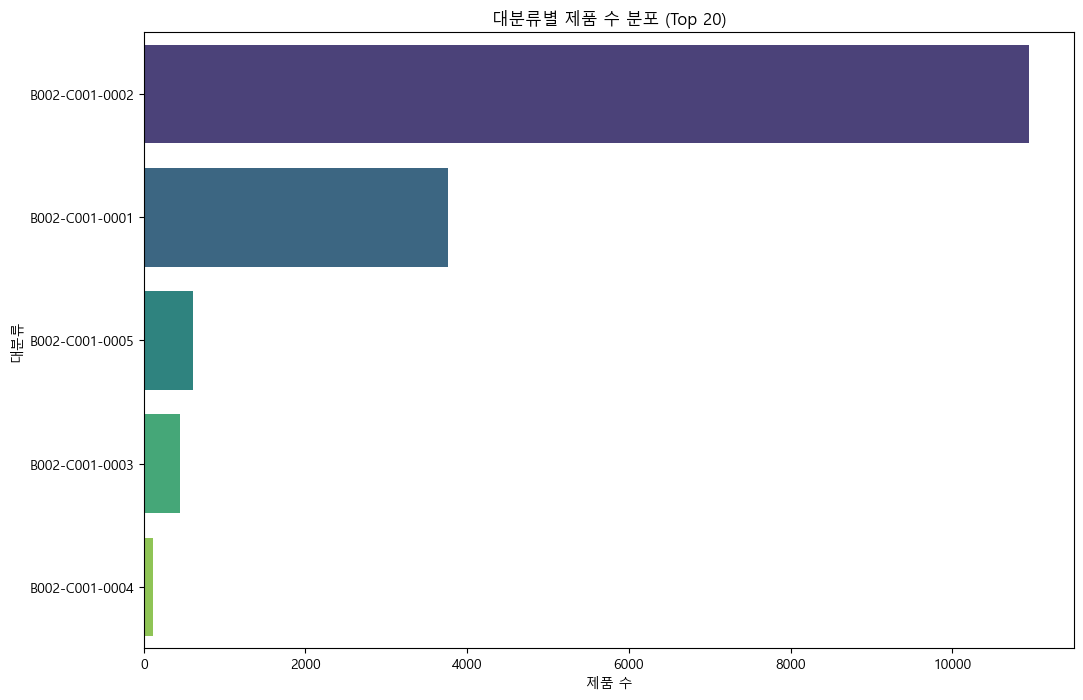

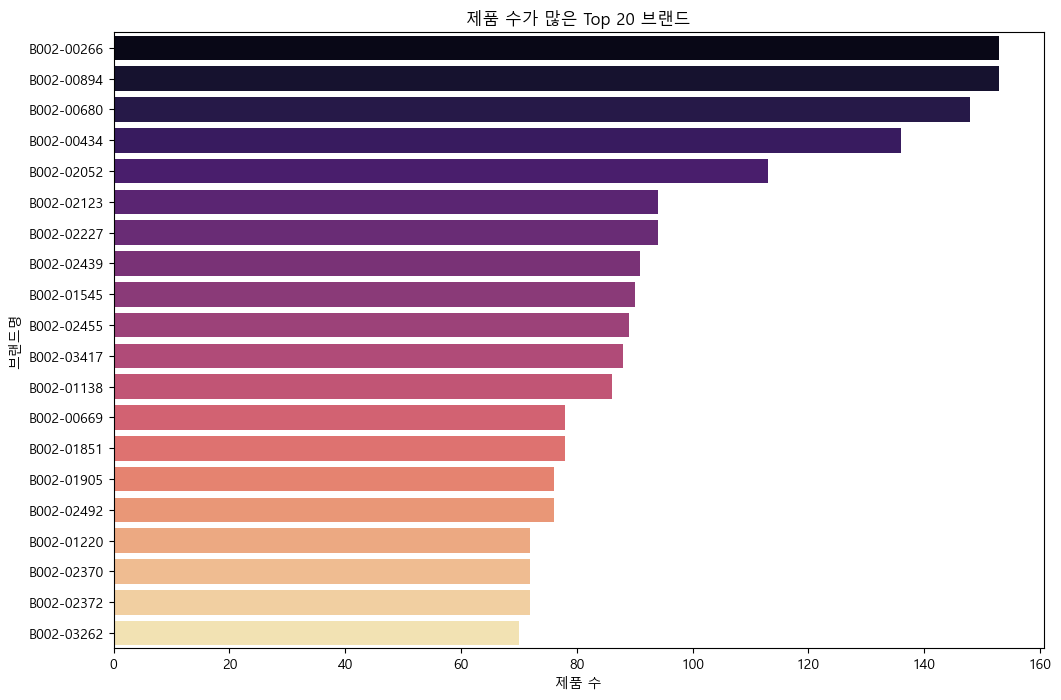

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 대분류별 제품 수 분포 시각화
plt.figure(figsize=(12, 8)) 
sns.countplot(data=train, y='대분류', order=train['대분류'].value_counts().index[:20], palette='viridis')
plt.title('대분류별 제품 수 분포 (Top 20)')
plt.xlabel('제품 수')
plt.ylabel('대분류')
plt.show()

# 제품 수가 많은 Top 20 브랜드
top_20_brands = train['브랜드'].value_counts().head(20)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_brands.values, y=top_20_brands.index, palette='magma')
plt.title('제품 수가 많은 Top 20 브랜드')
plt.xlabel('제품 수')
plt.ylabel('브랜드명')
plt.show()

### 3.2 판매량
대분류별로 일일 평균 판매량을 시각화하여 판매 패턴의 차이를 확인합니다.

In [95]:
# '20'으로 시작하는 실제 날짜 컬럼들만 리스트로 뽑습니다.
only_date_cols = [c for c in train.columns if str(c).startswith('20')]

# 각 제품별로 전체 기간의 판매량 합계 계산
train['total_sum'] = train[only_date_cols].sum(axis=1)

# 대분류별로 전체 판매량 합산
cat_total_sales = train.groupby('대분류')['total_sum'].sum()

# 판매 점유율(%) 계산
cat_sales_ratio = (cat_total_sales / cat_total_sales.sum()) * 100

# 제품당 평균 판매량 계산
cat_avg_sales = train.groupby('대분류')['total_sum'].mean()

# 결과 데이터프레임 생성
summary_df = pd.DataFrame({
    '전체 판매량 합계': cat_total_sales.astype(int),
    '판매 점유율(%)': cat_sales_ratio.round(2),
    '제품당 평균 판매량': cat_avg_sales.round(2)
}).sort_values(by='전체 판매량 합계', ascending=False)

print("--- 대분류별 판매 기여도 분석 ---")
print(summary_df)

--- 대분류별 판매 기여도 분석 ---
                전체 판매량 합계  판매 점유율(%)  제품당 평균 판매량
대분류                                             
B002-C001-0002   87218401      67.72     7962.24
B002-C001-0001   35441662      27.52     9405.96
B002-C001-0005    4961560       3.85     8093.90
B002-C001-0003    1078827       0.84     2429.79
B002-C001-0004      85411       0.07      769.47


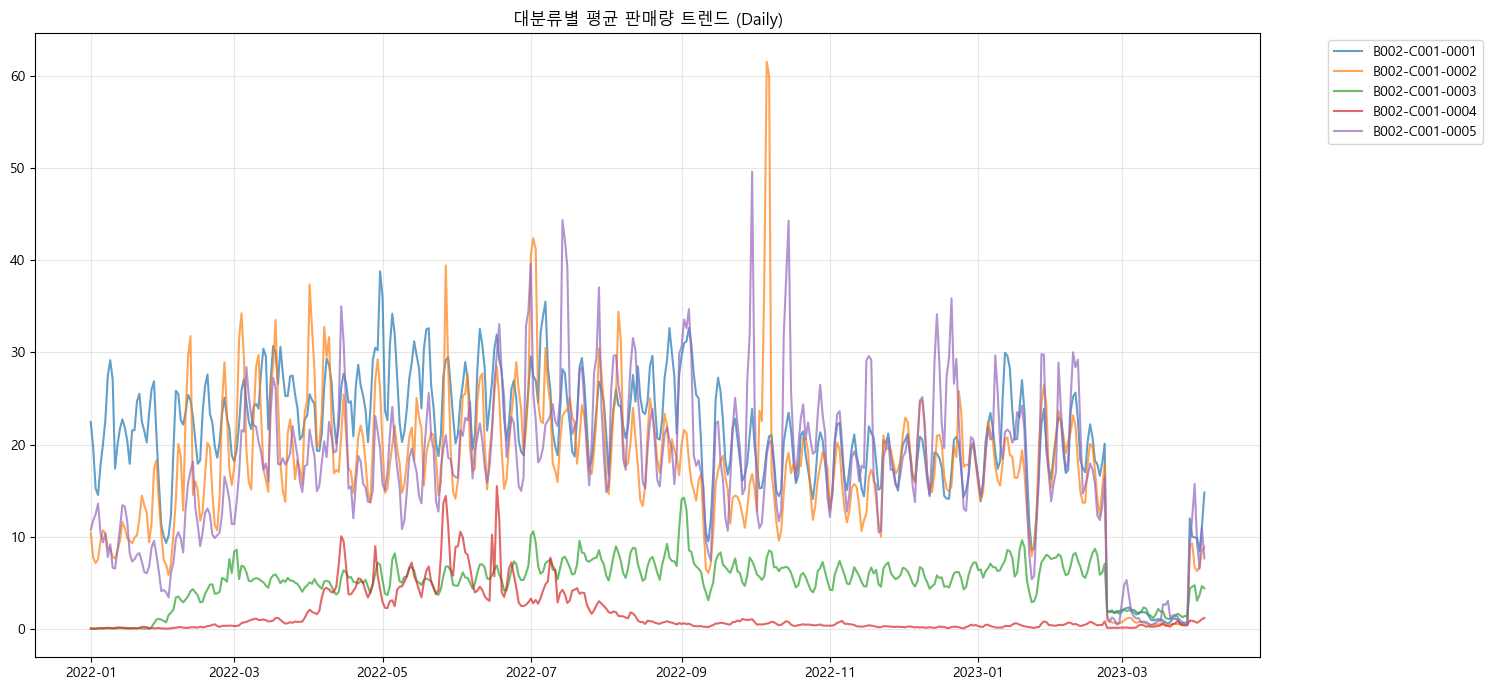

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜인 컬럼만 골라내기
date_cols = [c for c in train.columns if str(c).startswith('20')]

# 대분류별 평균 판매량 계산
category_sales = train.groupby('대분류')[date_cols].mean().T

# 인덱스를 날짜형으로 변환
category_sales.index = pd.to_datetime(category_sales.index)

# 시각화
plt.figure(figsize=(15, 7))
for col in category_sales.columns:
    plt.plot(category_sales.index, category_sales[col], label=col, alpha=0.7)

plt.title('대분류별 평균 판매량 트렌드 (Daily)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

월별 판매량을 확인해봅니다.

In [97]:
#'20'으로 시작하는 날짜 형식의 컬럼명만 리스트로 뽑습니다.
date_cols = [c for c in train.columns if str(c).startswith('20')]

# 모든 제품의 날짜별 판매 합계 계산 (Series 형태)
daily_total_sales = train[date_cols].sum(axis=0)

# 인덱스를 datetime 객체로 변환 (요일/월 추출을 위해 필수)
daily_total_sales.index = pd.to_datetime(daily_total_sales.index)

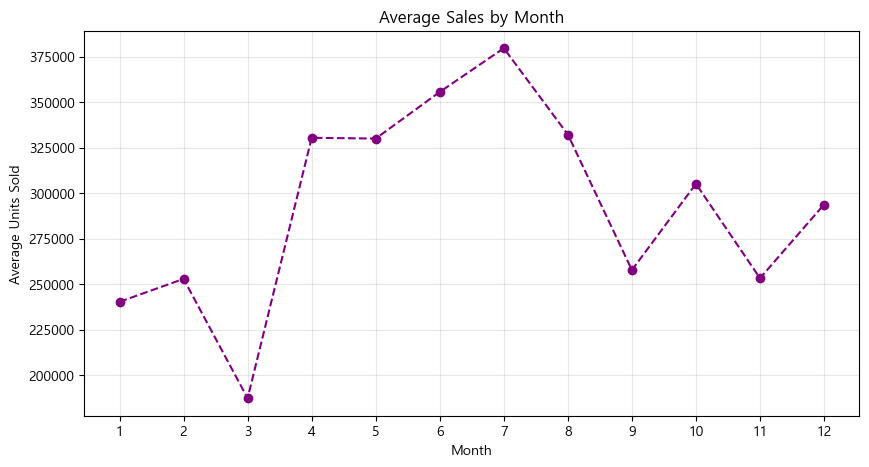

In [98]:
# 월 추출 (1월 ~ 12월)
monthly_sales = daily_total_sales.groupby(daily_total_sales.index.month).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='purple', linestyle='--')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

정점은 7월 : 일평균 판매량이 약 38만 건으로 1년 중 가장 높습니다. 6,7,8월이 다른 월보다 평균적으로 판매량이 높은 걸 보니 여름 시즌 특수나 대규모 프로모션이 있었을 가능성이 큽니다. 여름 시즌 특수를 받을 수 있는 제품(선풍기, 에어컨 등)이 판매량을 높여줬음을 추측해볼 수 있습니다.

급감하는 3월: 18만 건 수준으로 뚝 떨어지는데, 이는 개학 시즌이나 특정 소비 비수기 영향일 수 있습니다.

하반기 변동성: 8월 이후 다시 하락했다가 10월과 12월에 반등하는 'N자형' 패턴을 보입니다.

인사이트: 모델이 "지금이 몇 월인가"를 아는 것이 예측에 매우 중요합니다. 7월 데이터라면 평소보다 높게 예측하도록 유도해야합니다.

요일별 판매량을 확인해봅니다.

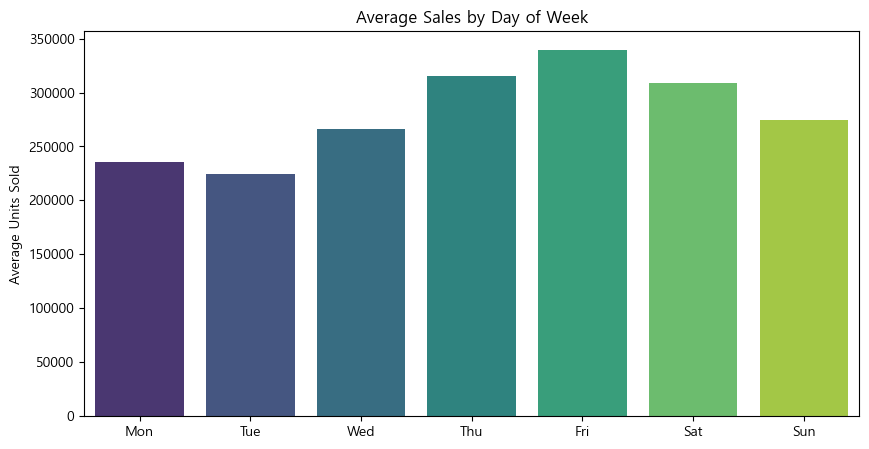

In [99]:
# 요일 추출 (0: 월요일, 6: 일요일)
weekday_sales = daily_total_sales.groupby(daily_total_sales.index.dayofweek).mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], y=weekday_sales.values, palette='viridis')
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Units Sold")
plt.show()

전체 제품의 요일별 평균 판매량을 분석한 결과, 금요일에 판매량이 가장 높고 화요일에 가장 낮은 뚜렷한 주간 주기성(Weekly Seasonality)을 확인했습니다. 이는 소비자의 주간 구매 패턴이 존재함을 시사하며, 향후 모델 학습 시 요일 정보(0~6)를 추가 피처로 활용할 수 있을 것 같습니다.

상위 5개 제품의 판매량을 시각화합니다.

In [100]:
import pandas as pd

# 날짜 컬럼만 골라내기
date_cols = [c for c in train.columns if str(c).startswith('20')]

# 제품별 전체 판매량 합계를 계산하여 새로운 컬럼으로 추가
train['total_sales'] = train[date_cols].sum(axis=1)

# 판매량(total_sales) 기준 상위 5개 제품 추출
top_5 = train.nlargest(5, 'total_sales')

# 결과 출력 (제품 ID, 대분류, 총 판매량)
print("--- 판매량 TOP 5 제품 리스트 ---")
display(top_5[['ID', '제품', '대분류', '중분류', '소분류', '브랜드', 'total_sales']])

--- 판매량 TOP 5 제품 리스트 ---


,ID,제품,대분류,중분류,소분류,브랜드,total_sales
485,485,B002-00113-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00113,3118885
11595,11595,B002-02723-00004,B002-C001-0002,B002-C002-0005,B002-C003-0025,B002-02723,2595146
12336,12336,B002-02920-00005,B002-C001-0002,B002-C002-0005,B002-C003-0041,B002-02920,2535587
4470,4470,B002-01069-00002,B002-C001-0001,B002-C002-0001,B002-C003-0004,B002-01069,2008250
3481,3481,B002-00809-00002,B002-C001-0002,B002-C002-0004,B002-C003-0021,B002-00809,1414800


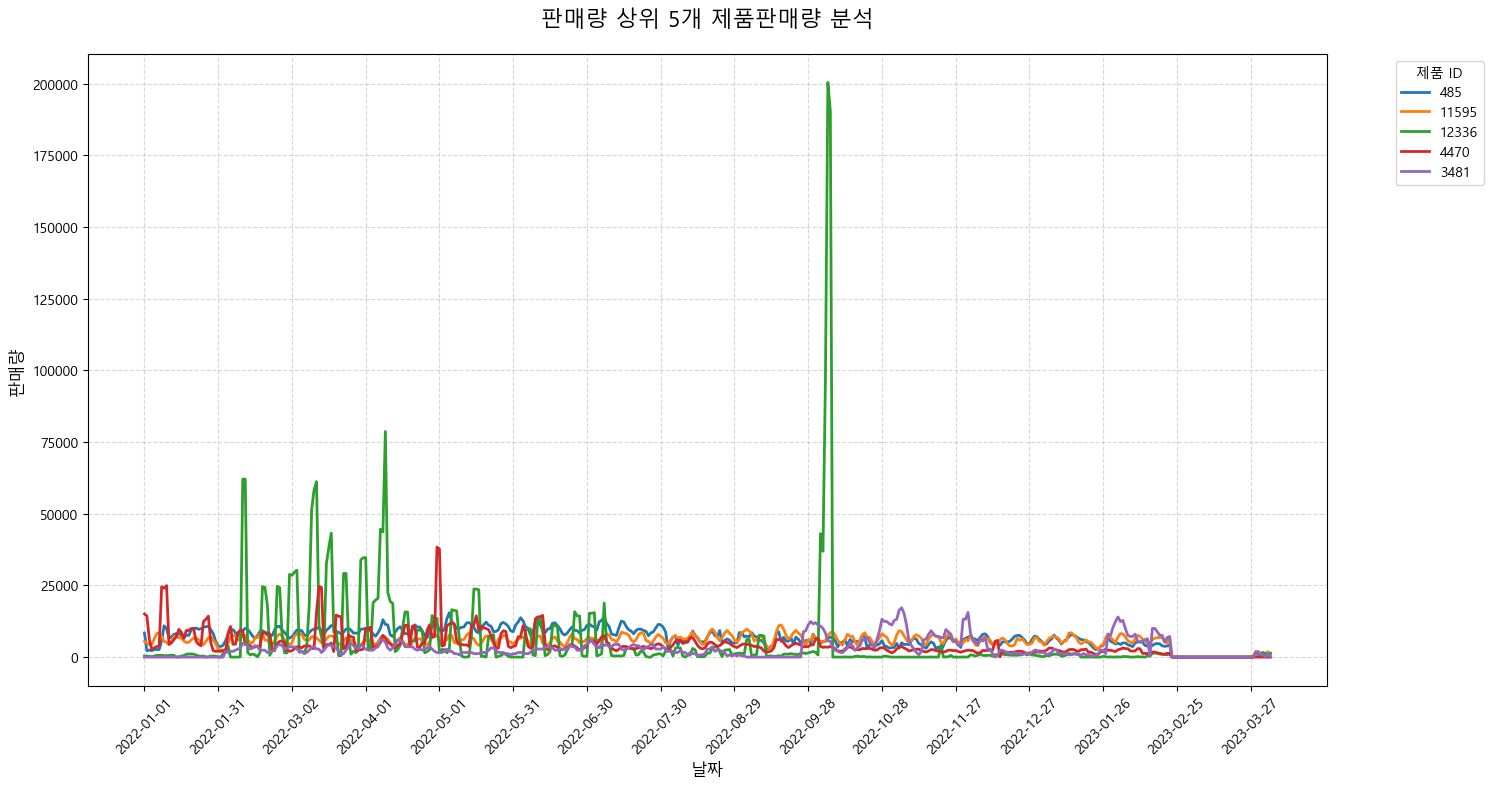

In [101]:
date_cols = [c for c in train.columns if str(c).startswith('20')]

top_5 = train.nlargest(5, 'total_sales').copy()

plt.figure(figsize=(15, 8))

for i, row in top_5.iterrows():
    
    product_id = row['ID'] 
    
    plt.plot(date_cols, row[date_cols], label=product_id, linewidth=2)

plt.title('판매량 상위 5개 제품판매량 분석', fontsize=16, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('판매량', fontsize=12)

plt.xticks(date_cols[::30], rotation=45)

plt.legend(title='제품 ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

270일~280일 지점(대략 2022년 10월경)에 초록색 제품(12336)의 판매량이 20만 건까지 어마어마하게 치솟은 게 보입니다. 이건 일반적인 판매가 아니라 역대급 할인 행사나 특정 이슈가 있었을 확률이 높습니다.

### 3.4 브랜드 검색량과 실제 판매량 상관관계
검색량이 판매의 선행 지표 역할을 하는지 확인해봅니다.

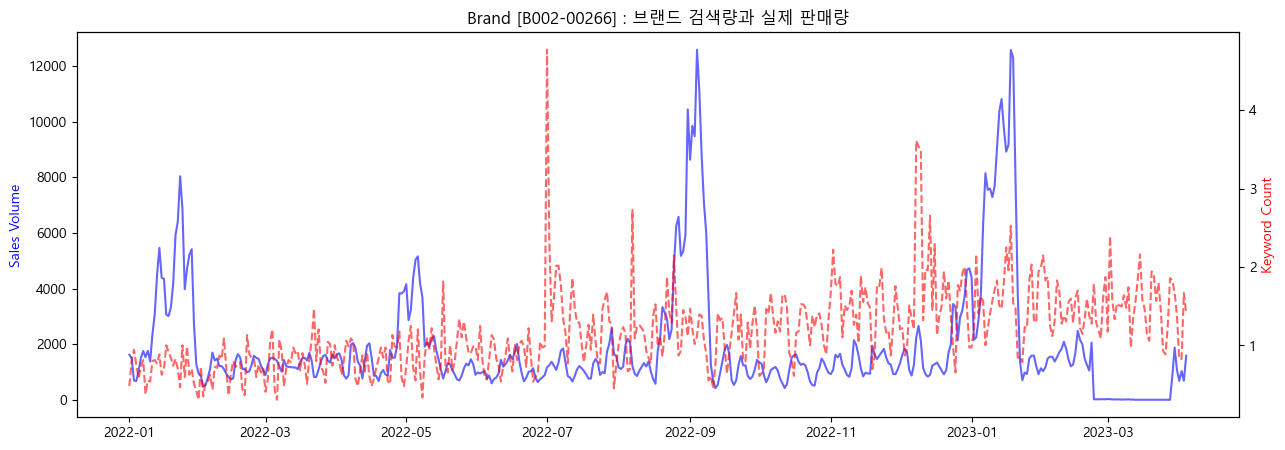

상관 계수: 0.0479


In [102]:
# 예시 브랜드 선택
sample_brand = train['브랜드'].value_counts().index[0]

# 판매량 데이터 추출
brand_sales_series = train[train['브랜드'] == sample_brand][date_cols].sum()

# brand_keyword_df(원본) -> brand_keyword_series(결과)
brand_keyword_series = brand_keyword[brand_keyword['브랜드'] == sample_brand][date_cols].sum()

# 시각화
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(pd.to_datetime(date_cols), brand_sales_series, color='blue', label='Actual Sales', alpha=0.6)
ax1.set_ylabel('Sales Volume', color='blue')

ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(date_cols), brand_keyword_series, color='red', linestyle='--', label='Keyword Search Count', alpha=0.6)
ax2.set_ylabel('Keyword Count', color='red')

plt.title(f'Brand [{sample_brand}] : 브랜드 검색량과 실제 판매량')
plt.show()

# 상관 계수 계산
print(f"상관 계수: {np.corrcoef(brand_sales_series, brand_keyword_series)[0,1]:.4f}")

검색량이 판매량을 '선행'하는 패턴 (신제품/프로모션 효과) : 그래프를 보면 빨간색 점선(검색량)이 먼저 치솟고, 뒤이어 파란색 실선(판매량)이 따라 올라가는 구간이 여러 번 관찰됩니다. 소비자들이 먼저 검색을 통해 정보를 탐색한 뒤, 실제 구매까지는 약간의 시간차가 발생하는 전형적인 구매 결정 과정을 보여줍니다. 모델을 만들 때, 오늘의 검색량뿐만 아니라 어제 혹은 며칠 전의 검색량을 변수(Feature)로 넣어주면 미래 판매량 예측 성능을 높일 수 있을 것 같습니다.<br>
검색량과 판매량의 '동기화' 구간 (강력한 세일) : 2022년 9월이나 2023년 1월경을 보면, 두 선이 거의 동시에 수직 상승합니다. 검색이 발생함과 동시에 즉각적인 구매가 일어나는 현상으로, 보통 강력한 가격 할인 이벤트나 라이브 커머스 같은 행사가 있었을 가능성이 큽니다. 이런 구간은 평소의 완만한 흐름과는 다른 '이벤트 데이터'이므로, 별도의 이벤트 플래그(0 또는 1)를 추가해 모델이 학습하게 해야 오차를 줄일 수 있을 것 같습니다.<br>
'판매 제로' 구간 (2023년 3월 이후) : 가장 눈에 띄는 부분은 그래프 마지막 부분인 2023년 3월부터 판매량이 '0'으로 수렴했다는 점입니다.검색량(빨간 점선)은 여전히 일정 수준 유지되고 있는데, 판매량만 바닥을 치고 있습니다.이는 소비자의 관심은 여전하지만 품절이 되었거나, 해당 채널에서 판매 중단이 되었을 가능성이 높습니다.

### 3.5 판매되지 않은 제품

In [103]:
# 날짜 컬럼들(2022-01-01 등)만 선택하여 sales_data 정의
date_cols = [c for c in train.columns if str(c).startswith('20')]
sales_data = train[date_cols] # 여기서 sales_data를 정의해줍니다!

# 판매 기록이 한 번이라도 있는지 여부 정의
has_sales = (sales_data > 0).any(axis=1)

# 출시일(launch_date) 컬럼 생성
train['launch_date'] = pd.to_datetime(sales_data.idxmax(axis=1).where(has_sales))

# 판매 기록 여부 확인 및 출력
total_products = len(train)
sold_products = train['launch_date'].notna().sum()
never_sold_products = train['launch_date'].isna().sum()

print(f"전체 제품 수: {total_products}개")
print(f"한 번이라도 판매된 제품: {sold_products}개 ({sold_products/total_products*100:.1f}%)")
print(f"판매 기록이 전혀 없는 제품: {never_sold_products}개 ({never_sold_products/total_products*100:.1f}%)")

전체 제품 수: 15890개
한 번이라도 판매된 제품: 15805개 (99.5%)
판매 기록이 전혀 없는 제품: 85개 (0.5%)


In [104]:
# 먼저 출시일(launch_date) 컬럼이 포함된 상태인지 확인하고 생성
date_cols = [c for c in train.columns if str(c).startswith('20')]
sales_data = train[date_cols]
has_sales = (sales_data > 0).any(axis=1)
train['launch_date'] = pd.to_datetime(sales_data.idxmax(axis=1).where(has_sales))

# train 데이터와 brand_keyword 데이터를 '브랜드' 기준으로 합치기
# (원본을 보호하기 위해 임시 변수 train_analysis를 사용합니다)
train_analysis = pd.merge(train, brand_keyword, on='브랜드', how='left', suffixes=('_sales', '_search'))

# 판매 기록이 없는(launch_date가 NaT인) 85개 제품의 인덱스 추출
no_sales_indices = train_analysis[train_analysis['launch_date'].isna()].index

# 해당 제품들의 '검색량' 컬럼(_search가 붙은 컬럼들)만 필터링
no_sales_search_data = train_analysis.loc[no_sales_indices].filter(like='_search')

# 결과 분석 및 출력
print(f"--- 판매 기록 없는 {len(no_sales_indices)}개 제품의 브랜드 검색량 통계 ---")
if not no_sales_search_data.empty:
    # 제품별 전체 기간 검색량 합계의 분포 확인
    search_sum_stats = no_sales_search_data.sum(axis=1).describe()
    print(search_sum_stats)
    
    # 만약 검색량이 0보다 큰 제품이 있다면 샘플 출력
    active_search_count = (no_sales_search_data.sum(axis=1) > 0).sum()
    print(f"\n* 검색량이 1이라도 존재하는 제품 수: {active_search_count}개")
else:
    print("검색량 데이터를 찾을 수 없습니다. 컬럼명을 확인해주세요.")

--- 판매 기록 없는 85개 제품의 브랜드 검색량 통계 ---
count       85.000000
mean      2400.455810
std       5182.620955
min          0.000000
25%         72.031470
50%        307.570481
75%       3222.144074
max      27931.366353
dtype: float64

* 검색량이 1이라도 존재하는 제품 수: 81개


브랜드 검색량은 평균 2400회로 브랜드가 인지도가 있는 것을 알 수 있고, 85개 중 81개가 검색 기록이 있다는 건, 이 브랜드들이 시장에 노출되어 활동 중이라는 증거입니다. 그런데도 판매 기록이 없다는 건 출시 예정 상품이어서 브랜드 페이지나 상품 상세 페이지는 미리 등록해두어 소비자들이 검색하고 들어오게 유도하지만, 실제 '구매 버튼'은 비활성화해둔 상태일 수 있습니다.
혹은 특정 제품이 원자재 수급 문제나 생산 중단으로 인해 데이터 수집 기간(2022~2023) 내내 '품절' 상태였을 가능성이 있습니다.<br>
판매 기록이 전혀 없는 85개 제품은 모델에게 아무런 패턴도 가르쳐줄 수 없는 노이즈에 가깝기때문에 전체적인 손실 함수(Loss)를 왜곡할 위험이 커서 모델 학습 전처리 단계에서 이 85개 제품은 제거(Drop)해야할 것 같습니다.

### 3.6 Zero-Sales (판매량 0)
얼마나 많은 제품이 판매가 전혀 발생하지 않았는지 확인합니다.

전체 데이터 중 판매량이 0인 데이터의 비율: 63.79%


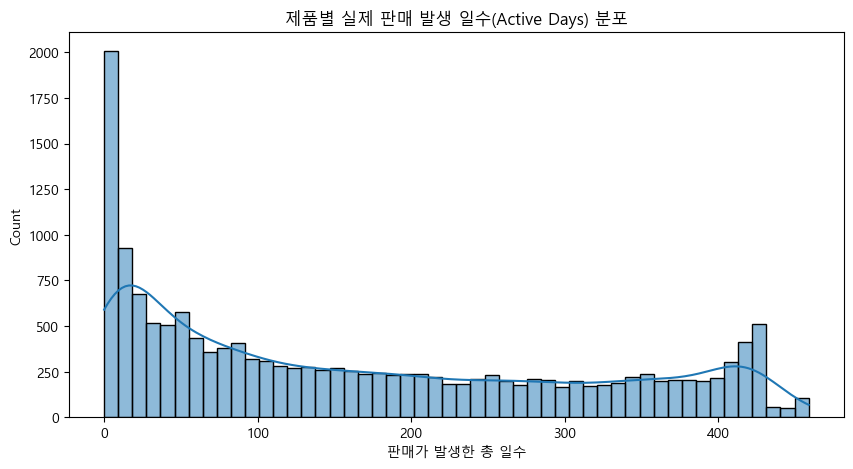

In [105]:
zero_sales_ratio = (train[date_cols] == 0).sum().sum() / (train[date_cols].size) * 100
print(f"전체 데이터 중 판매량이 0인 데이터의 비율: {zero_sales_ratio:.2f}%")

# 제품별 판매 발생 일수 분포
active_days = (train[date_cols] > 0).sum(axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(active_days, bins=50, kde=True)
plt.title('제품별 실제 판매 발생 일수(Active Days) 분포')
plt.xlabel('판매가 발생한 총 일수')
plt.show()

히스토그램에서 왼쪽(0~50일)에 데이터가 몰려 있는 것을 보아 출시 후 금방 판매가 중단되었거나 인기가 없는 제품이 대다수라는 뜻입니다. 반면 오른쪽 끝(400일 이상)에 솟아 있는 데이터는 쇼핑몰을 먹여 살리는 '스테디셀러' 제품들입니다.

전체 데이터 중 판매량이 0인 비율은 63.79%로, 이 데이터셋은 '희소 데이터(Sparse Data)' 특성을 가집니다.<br>

0인 데이터 처리 방법<br>
1. 로그 변환 (Log Transformation) : 0인 데이터는 먼저 로그 변환 해줘야 합니다. 큰 판매량 수치를 압축해서 0과의 격차를 줄여줍니다. 모델이 0의 늪에 빠지지 않고 "작은 변화"를 더 잘 감지하게 됩니다.<br>
2. 이동 평균(Moving Average) 변수 추가 : 단순히 그날의 판매량만 넣지 말고, '최근 7일간 평균 판매량' 같은 변수를 옆에 붙여줍니다. 오늘 판매량이 0이라도 "최근 일주일간은 좀 팔리고 있었다"는 정보를 주면, 모델이 내일 판매량을 예측할 때 훨씬 더 똑똑해집니다.
3. 스케일링 - MinMaxScaler : MinMaxScaler로 스케일링을 해줘서 0과 1 사이로 맞춥니다. 0이 많을 때 가장 무난합니다.

### 3.7 자기상관(ACF) 및 부분자기상관(PACF) 분석
과거의 판매량이 오늘의 판매량에 얼마나 직접적인 영향을 주는지 통계적으로 확인합니다.

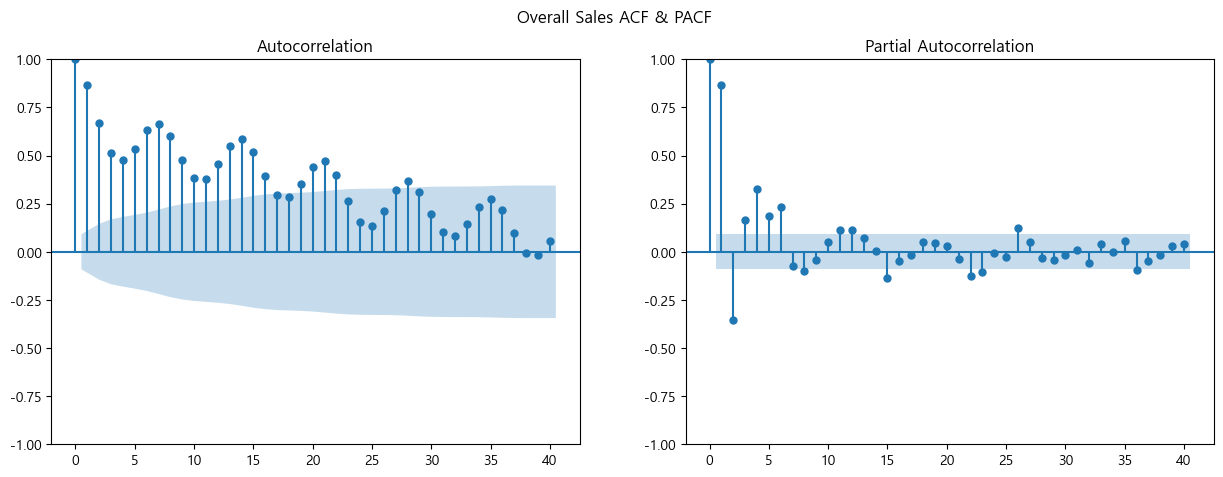

In [106]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(daily_total_sales, lags=40, ax=ax[0])
plot_pacf(daily_total_sales, lags=40, ax=ax[1])
plt.suptitle('Overall Sales ACF & PACF')
plt.show()

- **ACF(자기상관)**: 7일, 14일, 21일 간격으로 높은 상관관계가 반복적으로 나타납니다. 이는 데이터에 매우 뚜렷한 **주간 단위(7일 주기) 패턴**이 존재함을 의미합니다.
- **PACF(부분 자기상관)**: Lag 1(어제 판매량)에서 가장 높은 상관관계를 보이며, 이후 급격히 감소하다가 7일 지점에서 다시 튀는 모습을 보입니다. 
- **모델링 활용**: 모델이 '7일 전의 데이터'를 중요하게 참고하도록 유도할 필요가 있습니다.

### 3.8 교차 상관 분석
브랜드 검색량이 며칠의 시차(Lag)를 두고 판매량에 가장 큰 영향을 미치는지 분석합니다.

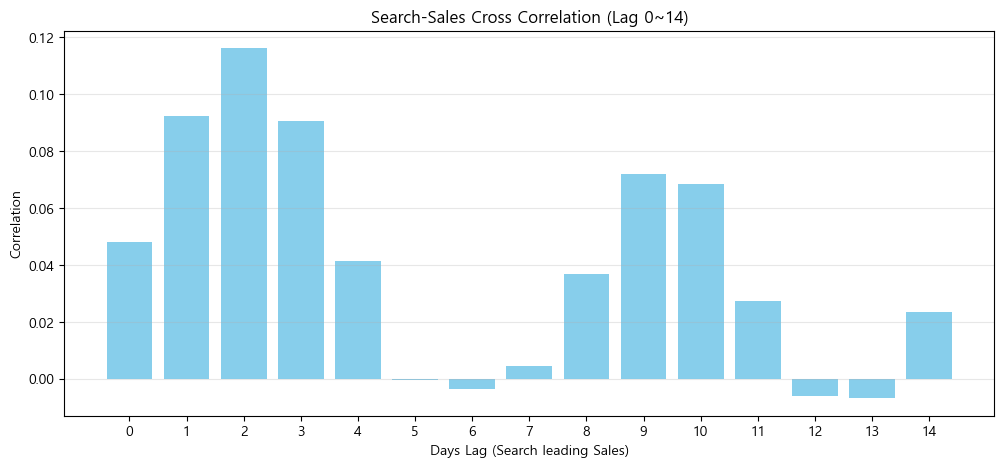

In [107]:
from statsmodels.tsa.stattools import ccf

# 예시 브랜드의 검색량과 판매량 시차 분석
cross_corr = ccf(brand_sales_series, brand_keyword_series, adjusted=False)

plt.figure(figsize=(12, 5))
plt.bar(range(15), cross_corr[:15], color='skyblue')
plt.title("Search-Sales Cross Correlation (Lag 0~14)")
plt.xlabel("Days Lag (Search leading Sales)")
plt.ylabel("Correlation")
plt.xticks(range(15))
plt.grid(axis='y', alpha=0.3)
plt.show()

- 검색량이 발생한 당일(Lag 0)의 상관관계가 높지만, **Lag 1~3 지점**에서도 유의미한 상관계수가 유지됩니다.
- 이는 소비자가 검색 후 구매까지 약 1~3일 정도의 고민 기간을 거친다는 것을 뜻합니다. 따라서 특성 공학 단계에서 `search_lag1`, `search_lag3` 변수를 추가한다면, 예측 성능 향상에 실질적인 도움을 줄 것 같습니다.

### 3.9 이동 통계량 (Rolling Statistics) 분석
매일의 급격한 변동(Noise)을 제거하고 전체적인 판매의 흐름과 변동성을 파악합니다.

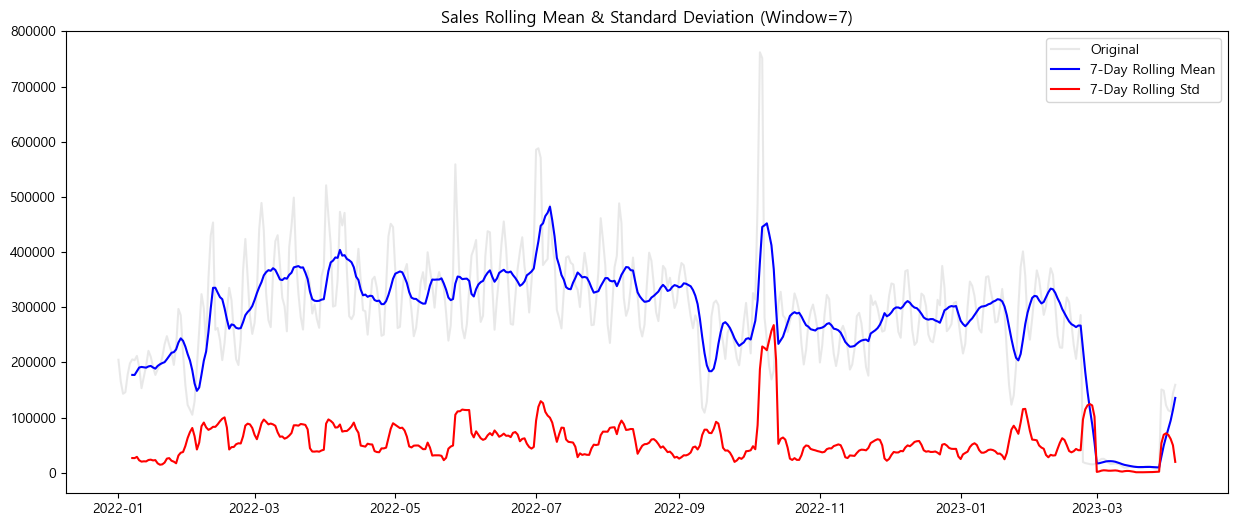

In [108]:
rolling_mean = daily_total_sales.rolling(window=7).mean()
rolling_std = daily_total_sales.rolling(window=7).std()

plt.figure(figsize=(15, 6))
plt.plot(daily_total_sales, color='lightgray', alpha=0.5, label='Original')
plt.plot(rolling_mean, color='blue', label='7-Day Rolling Mean')
plt.plot(rolling_std, color='red', label='7-Day Rolling Std')
plt.title("Sales Rolling Mean & Standard Deviation (Window=7)")
plt.legend()
plt.show()

- **Rolling Mean(파란색)**: 노이즈가 제거된 판매 트렌드를 보여줍니다. 2022년 하반기에 전반적으로 상승하다가 2023년 초에 급격히 꺾이는 추세를 명확히 확인할 수 있습니다.
- **Rolling Std(빨간색)**: 특정 구간(예: 프로모션 기간)에서 변동성이 급격히 커지는 것을 보여줍니다. 변동성이 큰 날은 예측 오차가 발생하기 쉬운 구간입니다.
- **모델링 활용**: 단순히 과거 수치만 넣는 것이 아니라, '최근 일주일간의 평균 판매 흐름'을 변수로 추가하면 모델이 추세를 더 잘 따라가게 될 것 같습니다.

### 3.10 카테고리별 시즌성 히트맵 (Category Seasonality)
대분류 카테고리별로 판매가 집중되는 월이 어떻게 다른지 비교 분석합니다.

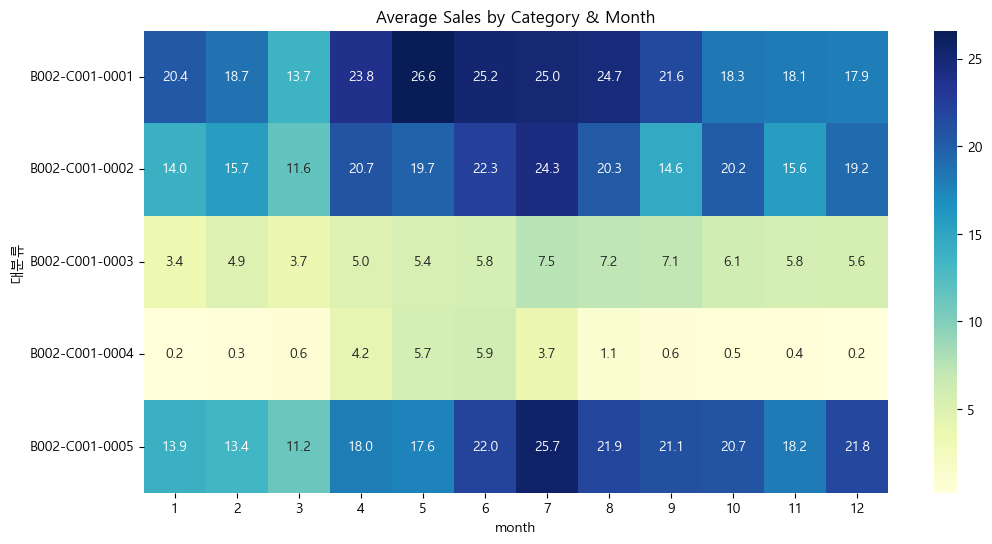

In [109]:
# 대분류별 월평균 판매량 계산
train_melted = train.melt(id_vars=['대분류'], value_vars=date_cols, var_name='date', value_name='sales')
train_melted['month'] = pd.to_datetime(train_melted['date']).dt.month
pivot_table = train_melted.pivot_table(index='대분류', columns='month', values='sales', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title("Average Sales by Category & Month")
plt.show()

- 특정 카테고리는 여름(7-8월)에 압도적으로 판매가 높고, 다른 카테고리는 연말에 반등하는 등 **카테고리별 시즌성**이 다르게 나타납니다.
- **모델링 활용**: 모든 제품을 하나의 모델로 학습시키기보다는, 입력 데이터에 카테고리 정보(대분류)를 강력하게 반영(Embedding 등)해야 카테고리 특유의 시즌성을 모델이 학습할 수 있습니다.

### 3.11 한국 주요 공휴일 및 쇼핑 시즌 분석
정기적인 공휴일과 명절이 판매량에 미치는 영향을 시각화하여 외부 변수의 중요성을 파악합니다.

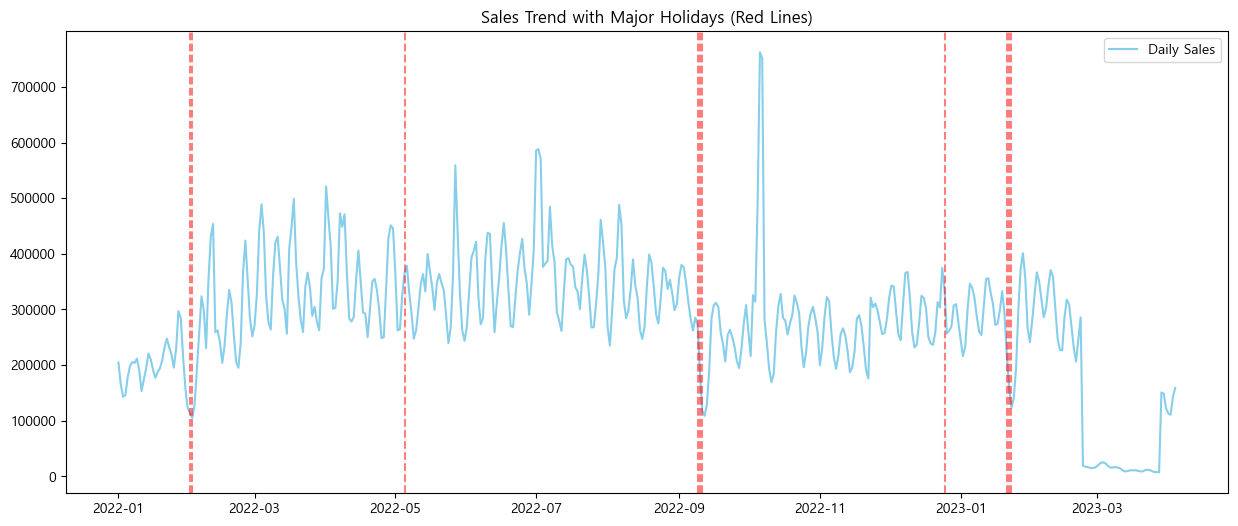

In [110]:
# 주요 공휴일 지정 (2022~2023)
holidays = [
    '2022-02-01', '2022-02-02', # 설날
    '2022-05-05', # 어린이날
    '2022-09-09', '2022-09-10', '2022-09-11', # 추석
    '2022-12-25', # 크리스마스
    '2023-01-21', '2023-01-22', '2023-01-23' # 설날
]
holidays = pd.to_datetime(holidays)

plt.figure(figsize=(15, 6))
plt.plot(daily_total_sales, color='skyblue', label='Daily Sales')
for holiday in holidays:
    if holiday in daily_total_sales.index:
        plt.axvline(holiday, color='red', linestyle='--', alpha=0.5)

plt.title("Sales Trend with Major Holidays (Red Lines)")
plt.legend()
plt.show()

- 붉은 점선(공휴일) 전후로 판매량이 급증하거나 급감하는 'V자' 혹은 '역V자' 패턴이 다수 관찰됩니다.
- **모델링 활용**: 단순히 과거 판매량 데이터만으로는 이러한 '외부 충격'을 완벽히 설명하기 어렵습니다. 따라서 예측 시점의 **공휴일 여부(Is_Holiday)** 피처를 추가하여 모델이 사전 대응하게 해야 합니다.

### 3.12 시계열 정상성(Stationarity) 분석
데이터가 통계적으로 일정한 패턴을 유지하는지(정상성) 확인하여 시계열 모델링의 안정성을 검토합니다.

In [112]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("데이터가 정상성을 띠고 있습니다. (귀무가설 기각)")
    else:
        print("데이터가 비정상성을 띠고 있습니다. 차분이 필요할 수 있습니다.")

print("--- Original Series ---")
check_stationarity(daily_total_sales)

print("\n--- 1st Order Differenced Series ---")
check_stationarity(daily_total_sales.diff().dropna())

--- Original Series ---
ADF Statistic: -1.8483
p-value: 0.3568
데이터가 비정상성을 띠고 있습니다. 차분이 필요할 수 있습니다.

--- 1st Order Differenced Series ---
ADF Statistic: -7.5020
p-value: 0.0000
데이터가 정상성을 띠고 있습니다. (귀무가설 기각)


- ADF Test 결과: 원본 데이터의 p-value가 0.3568로 나타나 **비정상성(Non-stationary)**을 띠는 것으로 확인되었습니다. 이는 데이터에 시간의 흐름에 따른 평균이나 분산의 변화(추세)가 포함되어 있음을 의미하며, 이대로 학습할 경우 모델이 특정 추세에 과적합(Overfitting)될 위험이 있습니다.
- 데이터 처리: 1차 차분(Differencing)을 수행한 결과, p-value가 0.0000으로 떨어지며 통계적 **정상성(Stationarity)**을 확보했습니다.
- 모델링 활용 전략: 1.  차분 데이터 활용: 모델 학습 시 원본값 대신 변동폭(차분값)을 입력값으로 사용하여 추세에 의한 왜곡을 방지합니다.
2.  구조적 보완: 모델이 현재 데이터의 강한 주기성(7일 단위 등)을 잘 포착할 수 있도록 **Window Size(과거 참조 기간)**를 충분히 설정하고, 필요시 추세를 별도로 학습하는 구조를 추가해야 할 것 같습니다.

### 3.13 시계열 분해 

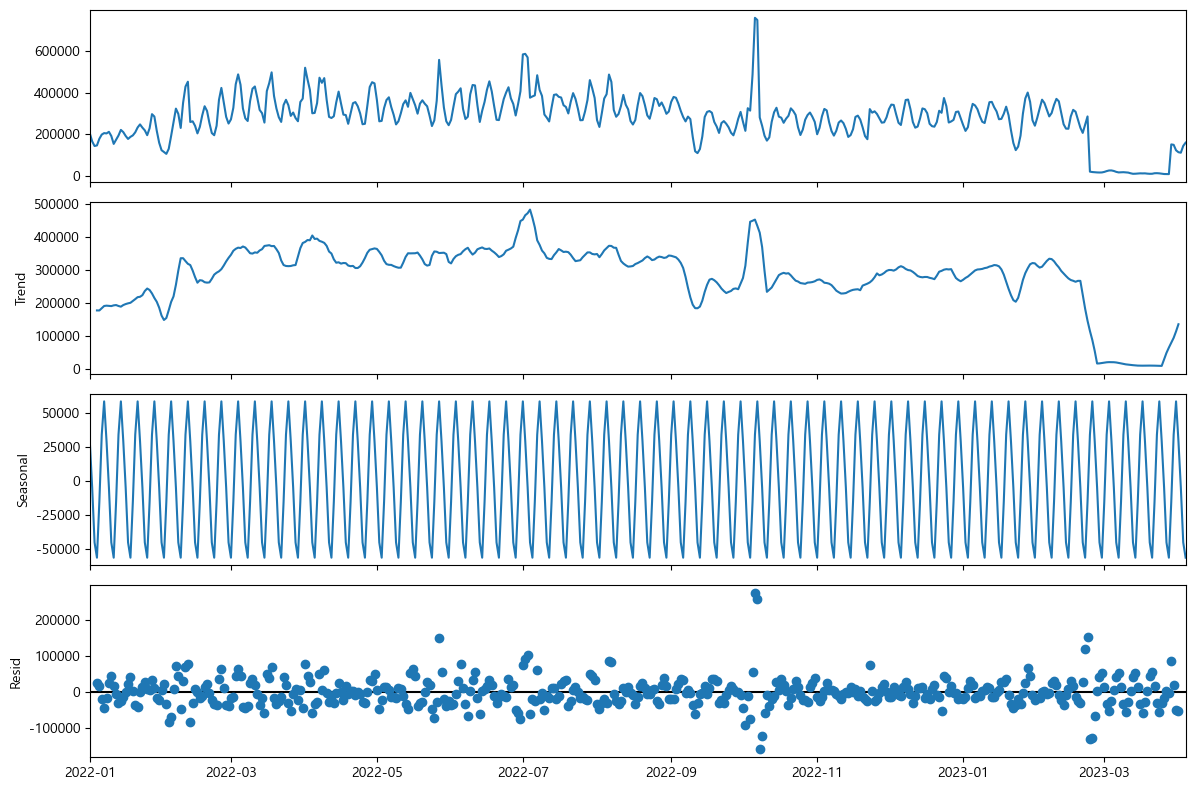

In [113]:
from statsmodels.tsa.seasonal import seasonal_decompose
# 주간 단위(period=7)로 분해
decomposition = seasonal_decompose(daily_total_sales, model='additive', period=7)

plt.rcParams['figure.figsize'] = [12, 8]
decomposition.plot()
plt.show()

Trend (추세): 전체적인 판매량의 흐름입니다. 2022년 7월경 정점을 찍고 내려왔다가 10월에 다시 튀는 모습을 보입니다.<br>
Seasonal (계절성): 규칙적인 파동입니다. 아주 일정한 간격으로 오르내리는 걸 보니 요일별 패턴이 매우 뚜렷하다는 것을 알 수 있습니다.<br>
Resid (잔차): 추세나 계절성으로 설명되지 않는 '돌발 변수'입니다. 2022년 10월경에 점들이 위로 크게 튀어 있습니다. 위에 그래프에서 확인한 이상치로 볼 수 있습니다.

## 4. 데이터 전처리 (Preprocessing)
효율적인 학습을 위해 데이터를 정제하고 3차원 텐서로 변환합니다.

In [ ]:
# 범주형 변수 처리
le = LabelEncoder()
for col in ['대분류', '중분류', '소분류', '브랜드']:
    train[col] = le.fit_transform(train[col])

# 스케일링
scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(train[date_cols].T).T # 제품별로 독립적 스케일링

print("Scaling Completed.")

## 5. 특성 공학 (Feature Engineering)

모델의 예측력을 높이기 위해 두 가지 핵심 피처를 생성합니다.
1. **이벤트 플래그 (is_event)**: 전체 판매량이 급증하는 날을 프로모션 데이로 간주합니다.
2. **검색량 시차 변수 (Search Lag)**: 검색이 판매보다 앞서는 패턴을 반영하기 위해 과거 검색량 데이터를 피처로 사용합니다.

In [ ]:
# 1. 이벤트 플래그 생성
daily_total_sales = train[date_cols].sum()
threshold = daily_total_sales.quantile(0.95) # 상위 5%를 이벤트 데이로 설정
is_event = (daily_total_sales > threshold).astype(int).values

# 2. 검색량 데이터와 시차 변수 생성 (예시 제품 기준)
def prepare_multivariate_data(product_idx, window_size=28):
    # 해당 제품의 브랜드 찾기
    brand_name = train.iloc[product_idx]['브랜드']
    
    # 판매량 데이터 (Target)
    sales_series = scaled_sales[product_idx]
    
    # 브랜드 검색량 데이터
    brand_search = keyword[keyword['브랜드'] == brand_name][date_cols].values.flatten()
    search_scaler = MinMaxScaler()
    brand_search_scaled = search_scaler.fit_transform(brand_search.reshape(-1, 1)).flatten()
    
    # 검색량 시차 변수 (1일 전, 3일 전)
    search_lag1 = np.roll(brand_search_scaled, 1)
    search_lag3 = np.roll(brand_search_scaled, 3)
    
    # 데이터 결합 (판매량, 이벤트플래그, 검색1일전, 검색3일전)
    # 데이터의 시작 부분(Lag로 인한 허수)은 제외하고 정렬
    combined_data = np.stack([
        sales_series, 
        is_event, 
        search_lag1, 
        search_lag3
    ], axis=1)
    
    X, y = [], []
    for i in range(window_size, len(combined_data)):
        X.append(combined_data[i-window_size:i])
        y.append(combined_data[i, 0]) # 타겟은 오늘의 판매량
        
    return np.array(X), np.array(y)

WINDOW_SIZE = 28
X_multi, y_multi = prepare_multivariate_data(product_idx=0, window_size=WINDOW_SIZE)

print(f"다변량 학습 데이터 형태 (Samples, Window, Features): {X_multi.shape}")
print(f"피처 구성: [판매량, 이벤트플래그, 검색Lag1, 검색Lag3]")

## 6. 모델링 (Multivariate GRU)

여러 개의 입력 변수를 동시에 처리할 수 있는 다변량 GRU 모델을 구축합니다.

In [ ]:
model = Sequential([
    # input_shape의 마지막 차원이 피처 개수(4)가 됩니다.
    GRU(128, input_shape=(WINDOW_SIZE, X_multi.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='huber', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_multi, y_multi, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=1)

## 7. 모델 평가 및 예측 (Evaluation & Predict)

In [ ]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# 예측 테스트
last_days = series_data[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)
prediction = model.predict(last_days)
inverse_prediction = scaler.inverse_transform([[prediction[0,0]]])

print(f"내일 예상 판매량: {inverse_prediction[0,0]:.2f} units")